### GW tutorial 3: Generation of data and matched filtering

Author: Melissa Lopez

Email: m.lopez@uu.nl

In [2]:
%matplotlib inline
         # so plots appear inside the notebook cell output
### pip install pycbc ### first needed
from pycbc.catalog import Merger
         # access to real grav-wave events(class Merger) from LIGO/VIRGO catalogs
import pycbc.psd, pycbc.noise
         # psd(power spectral density) - to model detector noise realisticly
         # noise: generation of synthetic noise consistent with a given PSD
import pylab
         # combines numpy and mathplotlib, not sure whether I need it
import matplotlib.pyplot as plt
import numpy as np
from pycbc.waveform import get_td_waveform
         # generates time-domain gravitational waveforms
from pycbc.detector import Detector
         # used to model real detectors
         #   - antenna patterns
         #   - sky location
         #   - time delay etc
import random
         # standard library for random choices

/usr/local/lib/python3.12/dist-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [1]:
!pip install pycbc
# there are a few warings, but nothing that leads to problems with the project

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.7 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver

Previously, we have plotted the PSD of different detectors. Some PSDs are from previous runs (O3), while some others are the design sensitivity of future detectors.

The PSD characterizes the noise of the detector, so we can generate detector noise accordingly.

**Exercise 1:** Load the `aligo_O4high.txt` PSD to [generate](https://pycbc.org/pycbc/latest/html/pycbc.noise.html#pycbc.noise.gaussian.noise_from_psd) some Gaussian data.

_Hint:_ Minimum frequency is 10 Hz, sampling rate 4096 Hz and we want 20s of duration

In [3]:
import os

path = "/content/aligo_O4high.txt"
print("Exists?", os.path.exists(path))
    # checking whether the file was uploaded correctly
if os.path.exists(path):
    print("Size (bytes):", os.path.getsize(path))
    # this check was added to ensure that the file is not empty

Exists? True
Size (bytes): 71136


In [4]:
!head -n 5 /content/aligo_O4high.txt
# see first 5 rows in the file to see that the content is in the right form
# Fourier freq(Hz)  Noise value(1/sqrt(Hz)) - amplitude spectral density

1.021659e+01 6.662774e-21
1.023975e+01 6.502138e-21
1.026296e+01 6.341156e-21
1.028622e+01 6.179826e-21
1.030954e+01 6.018081e-21


In [5]:
from pycbc.psd import from_txt
from pycbc.noise import noise_from_psd
from pycbc.types import TimeSeries
             # allows to create a timeseries object based on Parameters below

# Parameters
fs = 4096  # sampling frequencey(Hz)
duration = 20 # length of the data segment (sec), needed to control FFT size
delta_t = 1 / fs
delta_f = 1 / duration
flen = fs * duration // 2 + 1
     # bin is one discrete frequency slot in the Fourier transform
     # flen tells PyCBC how many distinct frequency points our data has
fmin = 10.3 # Hz
  # fmin = 10 Hz didn't work since the min value present in the file > 10.
  # sligtly increased min value works


# Load PSD
psd = from_txt(    # FrequencySeries object: numpy array + frequency metadata
    "/content/aligo_O4high.txt",
    flen,
    delta_f,
    fmin
)

# Generate random Gaussian noise
noise = noise_from_psd(  # numpy array datatype
    length=duration * fs,
    delta_t=delta_t, # tim spacing between samples(sec)
    psd=psd,
    seed=1234 # gives same noise realisation, needed for reproducibility
)

# Convert to TimeSeries
noise = TimeSeries(noise, delta_t=delta_t) # convert to TimeSeries datatype
# Now have a fake LIGO noise that statistically behaves like real detector noise
noise

In [6]:
noise.delta_t
# checking this value delta_t = 1 / fs = 1 / 4096 ≈ 0.00024414 s
# so we have:
# - correct sampling rate
# - no silent resampling
# - no mismatch between fs and TimeSeries

0.000244140625

As you can see. the generated noise is "coloured" according to the detector noise. Now, we would like to add a simulated gravitational wave signal in our detector noise.

**Exercise 2:** Using [this function](https://pycbc.org/pycbc/latest/html/pycbc.waveform.html#pycbc.waveform.waveform.get_td_waveform) to generate waveforms in time domain, provide the plus and cross polarization of a binary black hole merger of $m_{1} = m_{2} = 50$ at 2000 Mpc. Use the waveform approximant "IMRPhenomD". How does the waveform amplitude compare to the detector noise?

The waveform comes from the source, but it needs to be projected in the detector. [Project](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector.project_wave) the waveform on LIGO Livingston (L1) at random sky-location and polarization. You can specify your detector with [this](https://pycbc.org/pycbc/latest/html/pycbc.detector.html#pycbc.detector.ground.Detector) function. How does the waveform change because of this projection?

_Hint:_ Right ascension range is $[0, 2\pi]$, declination is $[-2\pi, 2\pi]$ and polarization is $[0, 2\pi]$.

In [7]:
"""
           Summary of the following code:
1) The code generates a binar black hole gravitational-wave signal(+ and x polarisations)
using a physical waveform and realistic source parameters.
2) It time-shifts and resizes the waveform so it fits cleanly inside a 20 sec data
segment and lines up sample by sample with simulated detector noise.
3) It compares the raw source-frame signal strength to the noise level to show that
the signal is intrinsically small before detector effects.
4) It then projects the waveform onto the LIGO Livingston detector, accounting fro
sky location, polarization, and detector orientation via antenna response factors.
5) Finally, it injects the projected signal into the noise, producing a realistic
mock strain time series similar to what a real LIGO detecotr would record.
"""
from pycbc.waveform import get_td_waveform
# Import a function that generates a GW waveform in the time domain (strain vs time)

from pycbc.detector import Detector
# Import Detector class that knows LIGO detector geometry + antenna response

import numpy as np



# --- 1) waveform (source frame) ---
m1 = m2 = 50     # Component masses in solar masses (50 Msun + 50 Msun)
distance = 2000  # Source distance in megaparsecs (Mpc)


# Generate the two GR polarization waveforms: h_plus (hp) and h_cross (hc)
hp, hc = get_td_waveform( # gravitational polarisations plus and cross
    approximant="IMRPhenomD",
      # Used for standard LIGO/Virgo analyses
      # IMR = Inspiral – Merger – Ringdown
      # Phenom = Phenomenological
      # D = specific calibrated version
    mass1=m1, mass2=m2,     # Mass parameters
    distance=distance,      # Controls amplitude scaling
    delta_t=delta_t,        # Sampling interval in seconds (matches data/noise ratio)
    f_lower=10.0            # Start frequency of waveform generation in Hz

)

# --- place merger at t=10 s in 20 s noise segment ---
t_merge = 10.0  #The merger occurs around 10 seconds into the segment
hp = hp.copy()    # Copy so that edits don't modify the original TimeSeries object
hc = hc.copy()    # Same for cross polarization

hp.start_time = float(hp.start_time) + t_merge
hc.start_time = float(hc.start_time) + t_merge

# Shift waveform start_time metadata forward by 10 s
hp.start_time = noise.start_time
hc.start_time = noise.start_time
hp.resize(len(noise))
hc.resize(len(noise))

# --- 2) compare to noise ---
noise_rms = float(np.std(noise.numpy()))
hp_peak = float(np.max(np.abs(hp.numpy())))
hc_peak = float(np.max(np.abs(hc.numpy())))

print("=== Source waveform vs noise (before detector projection) ===")
print(f"noise RMS:            {noise_rms:.3e}")
print(f"hp max abs value(hp_peak):         {hp_peak:.3e}")
print(f"hc max abs value(hc_peak):         {hc_peak:.3e}")
print(f"hp_peak / noise_rms:  {hp_peak/noise_rms:.3f}")
print(f"hc_peak / noise_rms:  {hc_peak/noise_rms:.3f}")

# --- 3) project onto LIGO Livingston (L1) ---
det = Detector("L1")
rng = np.random.default_rng(2026)
ra  = rng.uniform(0, 2*np.pi)
dec = rng.uniform(-np.pi/2, np.pi/2)
pol = rng.uniform(0, 2*np.pi)

h_L1 = det.project_wave(hp, hc, ra, dec, pol)

# --- force projected strain to match the noise segment (epoch + length) ---
h_L1 = h_L1.copy()
h_L1.start_time = noise.start_time
h_L1.resize(len(noise))

hL1_peak = float(np.max(np.abs(h_L1.numpy())))

print("\n=== After projection onto L1 ===")
print(f"(ra, dec, pol) = ({ra:.3f}, {dec:.3f}, {pol:.3f}) rad")
print(f"L1 projected peak(|h|): {hL1_peak:.3e}")
print(f"L1_peak / noise_rms:    {hL1_peak/noise_rms:.3f}")

# --- 4) inject into data ---
data = noise + h_L1

print("\nFinal data TimeSeries:")
print("len(data) =", len(data),
      "delta_t =", float(data.delta_t),
      "duration =", len(data) * float(data.delta_t))


=== Source waveform vs noise (before detector projection) ===
noise RMS:            5.938e-21
hp max abs value(hp_peak):         5.956e-22
hc max abs value(hc_peak):         5.915e-22
hp_peak / noise_rms:  0.100
hc_peak / noise_rms:  0.100

=== After projection onto L1 ===
(ra, dec, pol) = (1.124, 0.440, 2.936) rad
L1 projected peak(|h|): 4.371e-22
L1_peak / noise_rms:    0.074

Final data TimeSeries:
len(data) = 81920 delta_t = 0.000244140625 duration = 20.0


**Exercise 2:** From before our detector noise is 20s long. Add the GW into noise after 5s. We also need to get the first 4s to estimate the PSD in the next excercise. Make an overlaid plot with the total data, the portion of data where the GW is added and the data needed to estimate the PSD.

_Bonus:_ Can you also plot the GW signal?


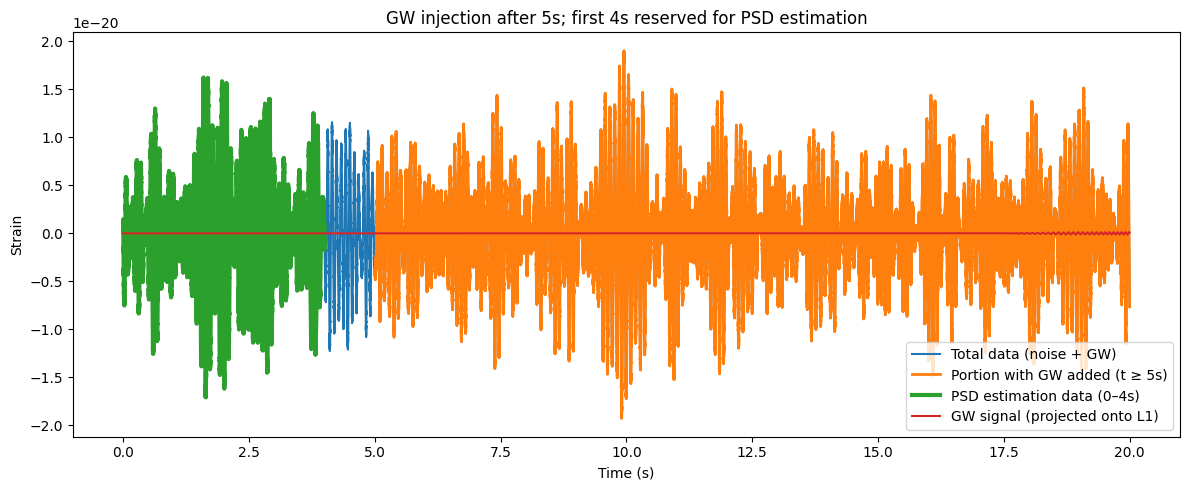

In [8]:
"""
  Summary of the following code
1) The code generates a binary black-hole gravitational-wave waveform(+ and x polarizations)
and shifts it so the signal starts at 5 seconds into a longer data segment.
2) A helper function embeds this function into a zero-padded time series that exactly
matche the noise segments's length and time grid.
(zero-padded <-> zeroes everywhere except where GW signal is placed)
3) The waveform is then projected onto the LIGO Livingston (L1) detector, using
random sky location and polarization to model the detector's antenna response.
4) The projected signal is added to the simulated detector noise, creating realistic
mock data where the first 4 seconds contain noise only(for PSD estimation) and the
GW appears later.
5) Finally, the code plots the total data, the noise-only region, the GW-injected
retion, and the injected signal itself to visually confirm the time and injection
behavior.
"""

import numpy as np
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
from pycbc.types import TimeSeries

# -----------------------
# Settings from the exercise
# -----------------------
t_inj_start = 5.0     # inject GW after 5s
t_psd_end   = 4.0     # first 4s for PSD estimation

# -----------------------
# 1) Generate BBH waveform (h_+, h_x)
# -----------------------
m1 = m2 = 50
distance = 2000  # Mpc

hp, hc = get_td_waveform(
    approximant="IMRPhenomD",
    mass1=m1, mass2=m2,
    distance=distance,
    delta_t=float(noise.delta_t),
    f_lower=10.0
)

# Shifting waveform so it STARTS at 5s in our segment
hp = hp.copy()
hc = hc.copy()
hp.start_time = float(hp.start_time) + (t_inj_start - float(hp.start_time))  # -> 5.0
hc.start_time = float(hc.start_time) + (t_inj_start - float(hc.start_time))  # -> 5.0



# -----------------------
# Helper: inserting TimeSeries into a segment (epoch+length of noise)
# -----------------------
def insert_into_segment(segment: TimeSeries, h: TimeSeries) -> TimeSeries:
    dt = float(segment.delta_t)
    out = TimeSeries(np.zeros(len(segment)), delta_t=dt)
    out.start_time = segment.start_time

    n_shift = int(round((float(h.start_time) - float(segment.start_time)) / dt))
    i0 = max(n_shift, 0)
    i1 = min(n_shift + len(h), len(segment))
    if i1 > i0:
        out[i0:i1] = h[(i0 - n_shift):(i1 - n_shift)]
    return out


# Building aligned hp/hc segments
hp_seg = insert_into_segment(noise, hp)
hc_seg = insert_into_segment(noise, hc)

# -----------------------
# 2) Projecting onto LIGO Livingston (L1) at random sky location/polarization
# -----------------------
det = Detector("L1")
rng = np.random.default_rng(2026)
ra  = rng.uniform(0, 2*np.pi)
dec = rng.uniform(-np.pi/2, np.pi/2)
pol = rng.uniform(0, 2*np.pi)

h_L1 = det.project_wave(hp_seg, hc_seg, ra, dec, pol)

# Some PyCBC builds can shift epoch; forcing the injected signal to start at 5s again
h_L1 = h_L1.copy()
h_L1.start_time = t_inj_start
h_L1_seg = insert_into_segment(noise, h_L1)

# -----------------------
# 3) Total data = noise + GW
# -----------------------
data = noise + h_L1_seg

# -----------------------
# 4) Plot: total, GW-added region (t>=5), PSD region (t<=4), bonus GW signal
# -----------------------
t = data.sample_times.numpy()
y = data.numpy()

mask_psd = (t >= 0.0) & (t <= t_psd_end)
mask_gw  = (t >= t_inj_start)

"""
     Plot overview:
The plot shows a 20 sec simulated LIGO strain(fractional changle in length of
detector arms caused by a GW) time series composed of detector noise plus an
injected GW signal.
1. The 0-4 sec(green) contain noise only and are reserved fot PSD estimation
with no GW present.
2. Starting from 5 sec, the data(orange) includes a GW injection, so the strain
contains both noise and signal.
3. The red curve shows the projected GW signal alone, which is much smaller than
the noise and not visible to eye.
 The plot illustrates why matched filtering is necessary: The GW is buried in
 noise even after injection.
"""

plt.figure(figsize=(12, 5))
plt.plot(t, y, label="Total data (noise + GW)")
plt.plot(t[mask_gw], y[mask_gw], linewidth=2, label="Portion with GW added (t ≥ 5s)")
plt.plot(t[mask_psd], y[mask_psd], linewidth=3, label="PSD estimation data (0–4s)")
plt.plot(t, h_L1_seg.numpy(), label="GW signal (projected onto L1)")

plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("GW injection after 5s; first 4s reserved for PSD estimation")
plt.legend()
plt.tight_layout()
plt.show()




**Exercise 3:** In a proper search we do not really have the PSD handy. We want to estimate the PSD with Welch's method (see [here](https://ccrma.stanford.edu/~jos/sasp/Welch_s_Method.html) for details), but we want to use the 4s of the beginning where the GW is not present using [this function](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.welch). Plot the estimated PSD. Note that before we used a dummy whitening, and this one is a bit better.

What is the $\Delta_f$ of the estimated PSD? What is $\Delta_f$ of the data we want to whiten to see the GW signal?

_Hint:_ `seg_stride (int)` is usually half of `seg_len`.


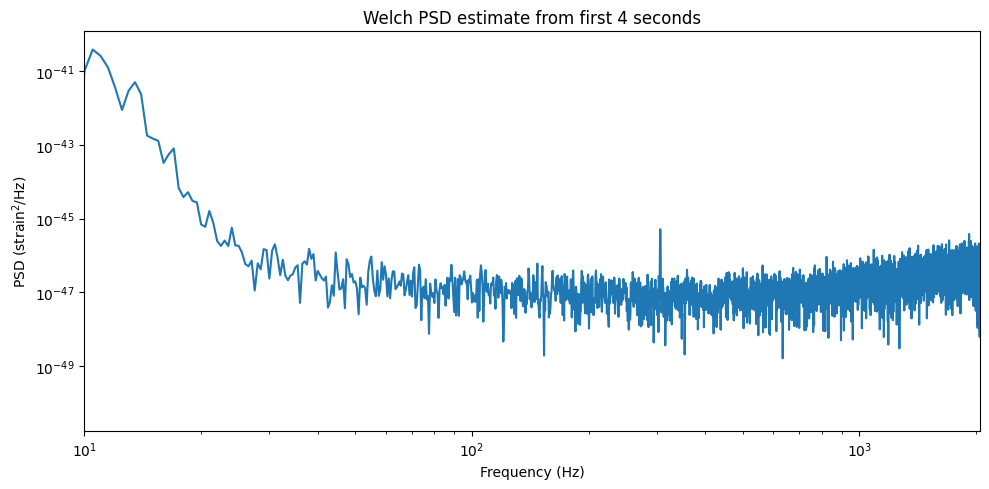

=== Δf results ===
Sampling rate fs: 4096 Hz
First-4s length: 16384 samples (4.00 s)
Welch seg_len: 8192 samples (2.00 s)
Welch seg_stride: 4096 samples (1.00 s)
Δf of estimated PSD (Welch): 0.500000 Hz
Δf of 20s data segment (for whitening full segment): 0.050000 Hz


In [9]:
"""
          Summary of the following code
1) We estimate the noise PSD using Welch's method from the first 4 sec
of data, where no GW is present.
2) The estimated PSD is then plotted on a log-log scale to visualise noise
as a function of frequency.
3) Finally we compare the PSD's frequency resolution with that of the full
20 sec data segment, and argue why interpolation is needed befor whitening.

"""
import numpy as np
import matplotlib.pyplot as plt
from pycbc.psd import welch

# --- Basics from your data ---
dt = float(data.delta_t)
fs = int(round(1.0 / dt))

# --- 1) Using first 4 seconds (GW not present) ---
n4 = int(4 * fs)
data_4s = data[:n4]

# --- 2) Welch PSD estimate ---
# Chooseing seg_len so we have multiple segments within 4s.
# Example: seg_len = 2s, seg_stride = 1s (half overlap, per hint)
seg_len = int(2 * fs)         # samples
seg_stride = seg_len // 2     # 50% overlap

psd_est = welch(data_4s, seg_len=seg_len, seg_stride=seg_stride)

# --- 3) Ploting PSD ---
f = psd_est.sample_frequencies

"""
Note:
  The plot shows that the noise is highly colored:
     - very loud at low frequences (~ 10-30 Hz)
     - much quiter in the mid frequences (~ 30-300 Hz)
  Using 2 sec Welch segments gives a PSD frequency resolution of
  delta_f = 0.5  Hz
  The full 20 sec data segment has a finer frequency resolution of
  delta_f = 0.05 Hz, showing that the PSD must be interpreted or
  resampled before it can be used to whiten the full data accurately.
"""


plt.figure(figsize=(10, 5))
plt.loglog(f, psd_est)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (strain$^2$/Hz)")
plt.title("Welch PSD estimate from first 4 seconds")
plt.xlim(10, fs/2)
plt.tight_layout()
plt.show()

# --- 4) Δf questions ---
# Δf of the estimated PSD is determined by Welch segment duration:
# Δf_psd = 1 / (seg_len*dt) = fs / seg_len
delta_f_psd = float(psd_est.delta_f)

# Δf of the data you want to whiten (the full 20s segment) if whitening as one chunk:
T_data = len(data) * dt
delta_f_data = 1.0 / T_data

print("=== Δf results ===")
print(f"Sampling rate fs: {fs} Hz")
print(f"First-4s length: {len(data_4s)} samples ({len(data_4s)*dt:.2f} s)")
print(f"Welch seg_len: {seg_len} samples ({seg_len/fs:.2f} s)")
print(f"Welch seg_stride: {seg_stride} samples ({seg_stride/fs:.2f} s)")
print(f"Δf of estimated PSD (Welch): {delta_f_psd:.6f} Hz")
print(f"Δf of 20s data segment (for whitening full segment): {delta_f_data:.6f} Hz")


Now that we have the PSD we need to interpolate it to match our data and then limit the filter length of 1 / PSD. After this, we can directly use this PSD to filter the data. Since the data has been highpassed above 12 Hz, and will have low values below this we need to informat the function to not include frequencies below this frequency.

**Exercise 4:** Use the functions [interpolate](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.interpolate) and [inverse_spectrum_truncation](https://pycbc.org/pycbc/latest/html/pycbc.psd.html#pycbc.psd.estimate.inverse_spectrum_truncation) to achieve a proper formatting of the PSD.

_Hint:_ `max_filter_len (int)` is $4 \times$ sampling_rate. Note that the original PSD has a minimum frequency of 12Hz.

In [10]:
from pycbc.psd import interpolate
# resample PSD to a new frequency spacing/length

from pycbc.psd import inverse_spectrum_truncation
# smooth/regularize PSD for stable whitening filters

"""
1. We prepare a noise PSD so it is compatible with the full data segment for
whitening/filtering
2. We interpolate the Welch-estimated PSD to match the data's frequency resolution
and requireed FFT length
3. Then The PSD is regularized using inverse spectrum truncation to limit
time-domain ringing and suppress unreliable low-frequency behavior
4. The final result is a well-behaved PSD with the correct frequency grid and
stability for whitening or matched filtering


Note: whitening is a transformation that makes the noise flat(white) in freq space,
so every freq has equal noise variance
"""


# --- basics ---
fs = int(round(1.0 / float(data.delta_t)))
                     # fs - sampling rate in Hz
                     # here data.delta_t - time step between samples(sec/sample)
T = len(data) * float(data.delta_t)
                     # total duration of this data segment in sec




# Frequency bins needed to whiten/filter the FULL data segment
delta_f_data = 1.0 / T
flen_data = len(data) // 2 + 1



# --- 1) interpolate PSD to match data's frequency resolution and length ---
psd_interp = interpolate(psd_est, delta_f=delta_f_data, length=flen_data)
               # here psd_est is our origian PSD estimate(from Welch approach)

# --- 2) truncate inverse spectrum to limit filter ringing ---
max_filter_len = 4 * fs          # 4 * sampling_rate (in samples)
low_frequency_cutoff = 12.0      # original PSD minimum frequency / highpass

psd_final = inverse_spectrum_truncation(
    psd_interp,
    max_filter_len=max_filter_len,
    low_frequency_cutoff=low_frequency_cutoff
)

print("=== PSD formatting summary ===")
print("fs:", fs, "Hz")
print("data duration:", T, "s")
print("data delta_f:", delta_f_data, "Hz")
print("flen_data:", flen_data)
print("max_filter_len:", max_filter_len, "samples =", max_filter_len/fs, "s")
print("low_frequency_cutoff:", low_frequency_cutoff, "Hz")
print("psd_final delta_f:", float(psd_final.delta_f), "Hz")
print("psd_final length:", len(psd_final))


=== PSD formatting summary ===
fs: 4096 Hz
data duration: 20.0 s
data delta_f: 0.05 Hz
flen_data: 40961
max_filter_len: 16384 samples = 4.0 s
low_frequency_cutoff: 12.0 Hz
psd_final delta_f: 0.05 Hz
psd_final length: 40961


Now that the PSD is ready, we can whiten the data. Before we used a PyCBC function, but mathematically this is defined as

\begin{equation}
\tilde{d_w}(f) = \tilde{d}(f)/S_{n}^{-1/2}(f)
\end{equation}
where $\tilde{d}$ and $\tilde{d_w}(f)$ are the Fourier transform of the coloured data and whitened data, respectively.

**Exercise 5:** Whiten the data using the interpolated PSD. Crop 5s at the beginning and the end to avoid border effects (_aliasing_) and bandpass it as in the previous exercise. Can you see the GW signal?

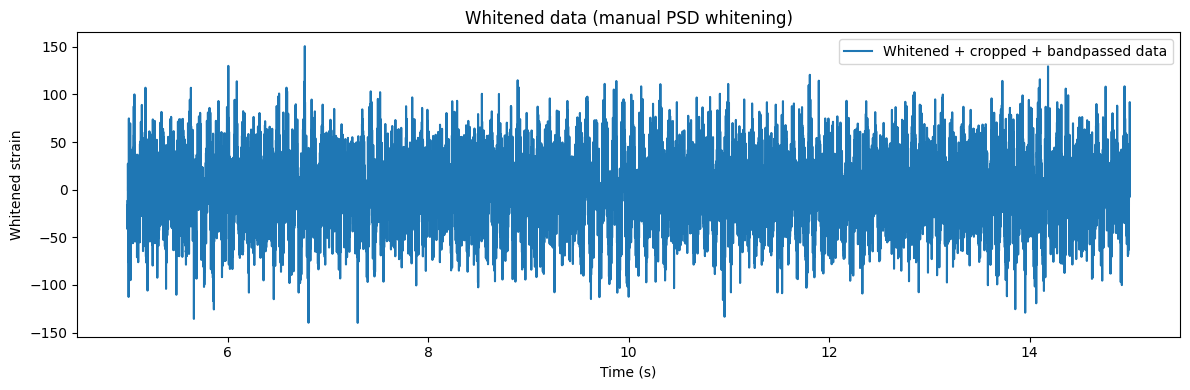

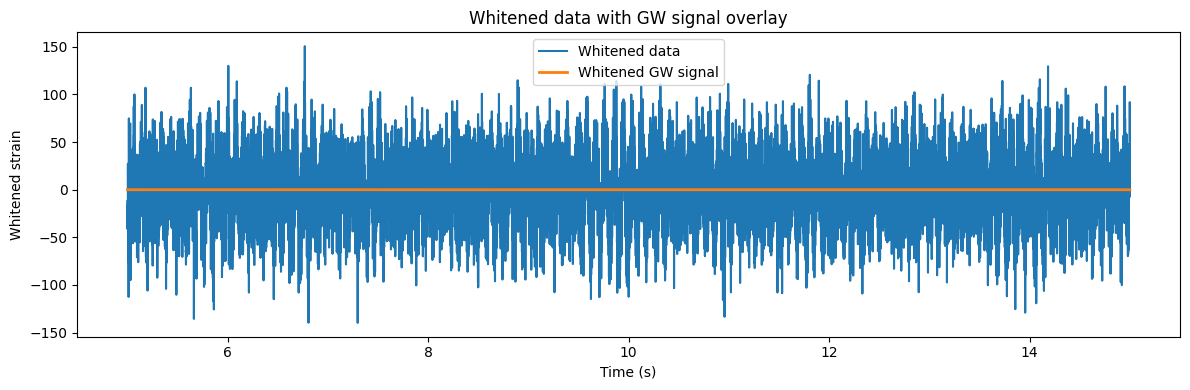

In [14]:
"""
       Manual whitening + crop + bandpass + plot
  We take noisy detector strain data, whiten it using PSD,
remove edge artifacts, bandpass it to the useful frequencey
range and plot it.
 The we do the same to the injected GW signal and overlay it.
"""


import numpy as np
import matplotlib.pyplot as plt
from pycbc.filter import highpass, lowpass
           # FIR(Fine Impulse Response)/IIR(Infinite Impulse Response)
           # style filtering helpers for TimeSeries


# ----------------------------------------
# 1) Manual whitening in frequency domain
# ----------------------------------------


# Convert the time-domain strain data x(t) into a frequency-domain
# series X(f) via FFT. Whitening is easiest in frequency domain because
# it is a simple division by sqrt(PSD).
data_fd = data.to_frequencyseries()



# The PSD must have the same frequency grid (same number of bins)
# as the FFT of the data. If this fails, your PSD was computed/interpolated
# to a different length or delta_f.
assert len(psd_final) == len(data_fd)


# Whitening step:
# For noise with power spectral density S_n(f), dividing by sqrt(S_n(f)) makes the noise
# approximately flat ("white") across frequencies (equal variance per frequency bin).
# This also down-weights frequencies where the detector noise is large.
white_fd = data_fd / np.sqrt(psd_final)

# Converting the whitened spectrum back to time domain to get a whitened time series.
white_td = white_fd.to_timeseries()



# --------------------------------
# 2) Crop 5 s at beginning and end
# --------------------------------

# Compute sampling rate fs from the time step delta_t (seconds per sample).
fs = int(round(1.0 / float(data.delta_t)))

# Number of samples corresponding to 5 seconds.
n_crop = int(5 * fs)



# Removing first and last 5 seconds of the whitened time series.
# Why: FFT-based operations and filters often cause "edge transients"/ringing near boundaries.
# Cropping discards those contaminated regions so plots/analysis use the stable middle.
white_crop = white_td[n_crop : len(white_td) - n_crop]



# -------------------------------------------------------
# 3) Bandpass using pycbc.filter (NOT TimeSeries methods)
# -------------------------------------------------------


# Defining the frequency band of interest (typical for LIGO-like analyses).
# Below ~10–20 Hz: seismic / messy behavior; above a few hundred Hz: often less SNR for BBH.
f_lo = 12.0
f_hi = 512.0


# Applying a highpass then a lowpass => overall bandpass [f_lo, f_hi].
# This removes remaining low-frequency drift and very high-frequency noise.
white_bp = lowpass(highpass(white_crop, f_lo), f_hi)



# -----------------------
# 4) Plot whitened data
# -----------------------
"""
Top plot: It shows the whitened, cropped, band-passed detector data.
After whitening, the noise has roughly constant variance across frequencies,
so in time domain it looks like zero-mean, stationary noise with
no obvious trends.

Bottom plot: The same whitened data is shown with the whitened injected GW signal
overlaid. The GW signal is much smaller than the noise, so it appears
almost flat and is not visually distinguishable without matched filtering.

Note: Whitening makes the noise well-behaved, but GW signals are still
buried in noise—they become detectable only through matched filtering, not by eye.
"""


# PyCBC TimeSeries has a time axis (sample_times) and values; convert both to NumPy for plotting.
t = white_bp.sample_times.numpy()
y = white_bp.numpy()

plt.figure(figsize=(12, 4))
plt.plot(t, y, label="Whitened + cropped + bandpassed data")
plt.xlabel("Time (s)")
plt.ylabel("Whitened strain")
plt.title("Whitened data (manual PSD whitening)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------
# 5) BONUS: overlay whitened GW signal
# -----------------------
try:
    gw_fd = h_L1_seg.to_frequencyseries()
    gw_white_fd = gw_fd / np.sqrt(psd_final)
    gw_white_td = gw_white_fd.to_timeseries()
    gw_white_crop = gw_white_td[n_crop : len(gw_white_td) - n_crop]
    gw_white_bp = lowpass(highpass(gw_white_crop, f_lo), f_hi)

    plt.figure(figsize=(12, 4))
    plt.plot(t, y, label="Whitened data")
    plt.plot(
        gw_white_bp.sample_times.numpy(),
        gw_white_bp.numpy(),
        label="Whitened GW signal",
        linewidth=2,
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Whitened strain")
    plt.title("Whitened data with GW signal overlay")
    plt.legend()
    plt.tight_layout()
    plt.show()
except NameError:
    pass


So far, we buried a GW signal  $h(t)$ in stationary and Gaussian noise $n(t)$ with zero mean, such that $s(t) = h(t) + n(t)$. Given the optimal filter  $K(t)$,

\begin{equation}
\label{eq:filteredsignal}
\hat{s} = \int_{-\infty}^{\infty}  K(t)s(t) dt = \int_{-\infty}^{\infty} \tilde{K}(f)^{*}\tilde{s}(f) df, \quad \text{ where }  \tilde{s}(f) = \int_{-\infty}^{\infty} s(t)e^{-2 \pi i ft}dt
\end{equation}
where $\hat{s}$ is the filtered value of $s(t)$, $^*$ represents the complex conjugate, and $\tilde{\cdot }\ $ the Fourier transform.

The detection statistic that is maximised by the optimal filter $K(t)$  will be the SNR, defined as $\rho = S/N$. $S$ is the expected value of $\hat{s}$ when $h(t) \neq 0$, while $N$ is the squared root of the noise variance when $h(t) =0$. It can be demonstrated that the optimal filter $K(t)$ is the model of the GW signal itself, known as _template_.

The fundamental modelled detection technique is called "matched filtering", since the filter function is chosen to "match" the signal we are looking for. We can write the SNR between an unknown time series $s(t)$ and the template $h_{m}$ as

\begin{equation}
\label{eq:wienerscalar}
\rho =  4 \text{Re} \int_{0}^{\infty} \frac{\tilde{s}^{*}(f)}{S_{n}(f)} \tilde{h_{m}}(f) df.
\end{equation}



**Exercise 6:** Use the [matched_filter](https://pycbc.org/pycbc/latest/html/pycbc.filter.html#pycbc.filter.matchedfilter.matched_filter) function to filter the coloured data with the template. Crop the SNR time series 5s at each side and plot it together with the whitened data. Where is the GW signal? Note that the y-axis of the whitened data is _amplitude_ and the y-axis of the SNR timeseries is _SNR_.

How much is the maximum of the absolute value of the SNR time series? If it is larger than 5 it will generate a "trigger" for further analysis. Will the trigger be generated?

Note that the parameter space of GW signals is vast, so to find these signals, we will need to create a template bank and do this process for thousands of templates. Then, this becomes a high-performance computing problem!

_Hint_: you need to [resize](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.array.Array.resize) the template and use [cyclic_time_shift](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.frequencyseries.FrequencySeries.cyclic_time_shift)

Max |SNR| (cropped): 8.662749417857023
Trigger generated (|SNR| > 5)? True


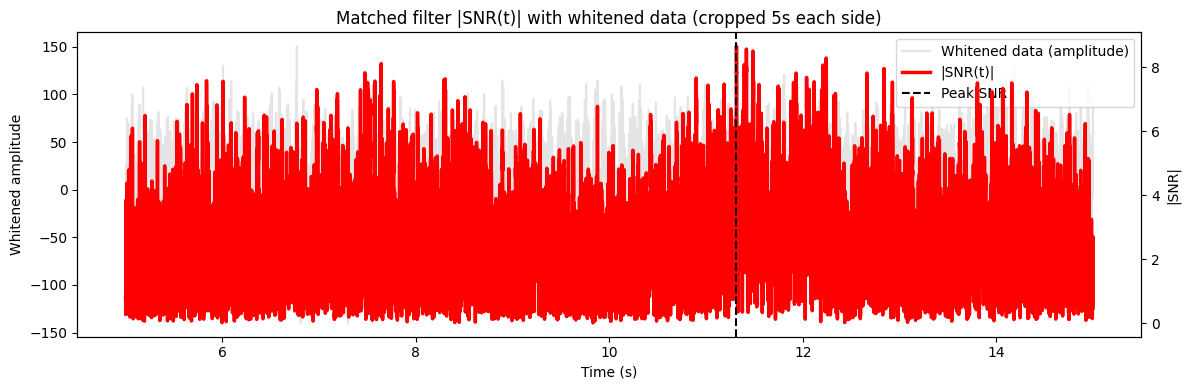

In [16]:
"""
Matched filtering: SNR time series + plot with whitened data + trigger check
Goal: compute matched-filter SNR(t) for data using a template waveform and the PSD,
then find the max SNR (trigger check) and plot SNR alongside whitened data.
"""


import numpy as np
import matplotlib.pyplot as plt

# matched_filter computes the SNR time series given (template, data, PSD).
# highpass/lowpass are used later for plotting a bandpassed whitened timeseries.
from pycbc.filter import matched_filter, highpass, lowpass

# get_td_waveform generates GR waveform polarizations (h_plus, h_cross) in time domain.
from pycbc.waveform import get_td_waveform

# Detector knows geometry + antenna response to project (hp,hc) onto a detector strain time series.
from pycbc.detector import Detector

# TimeSeries is PyCBC's time-domain data container (with delta_t, start_time, etc.)
from pycbc.types import TimeSeries

# -----------------------
# 0) Basic constants
# -----------------------

# dt = time step between samples in seconds (1/4096).
dt = float(data.delta_t)

# fs = sampling rate in Hz = samples per second.
fs = int(round(1.0 / dt))

# Low-frequency cutoff for matched filtering and plotting.
# We ignore stuff below 12 Hz because it’s unreliable/very noisy.
f_low = 12.0


# We crop edges (5s) to avoid FFT/filter boundary artifacts.
crop_s = 5.0
n_crop = int(crop_s * fs) # number of samples to crop from each end


# -----------------------
# 1) Building a TEMPLATE
# -----------------------

if "h_L1_seg" in globals():
    template_td = h_L1_seg.copy()
else:
    # Fallback template (may not match your injection if your injection used different sky angles)
    m1 = m2 = 50
    distance = 2000  # Mpc

# Generating the two GR polarizations in the SOURCE FRAME:
# hp = h_plus(t), hc = h_cross(t)
    hp, hc = get_td_waveform(
        approximant="IMRPhenomD",
        mass1=m1, mass2=m2,
        distance=distance,
        delta_t=dt,      # must match the data sampling
        f_lower=10.0     # waveform generation starts at 10 Hz (not same as filtering cutoff)
    )

    # If sky parameters (ra, dec, pol) aren’t defined already, create deterministic ones
    # so results are reproducible.
    if not all(name in globals() for name in ["ra", "dec", "pol"]):
        rng = np.random.default_rng(2026)
        ra  = rng.uniform(0, 2*np.pi)               # right ascension
        dec = rng.uniform(-np.pi/2, np.pi/2)        # declination
        pol = rng.uniform(0, 2*np.pi)               # polarization angle


    # Creating a detector object for LIGO Livingston (L1)
    det = Detector("L1")


    # Here we put coalescence around the injection start time (5s) using cyclic_time_shift (as hinted)
    t_inj = 5.0

    # cyclic_time_shift shifts a waveform in time by applying a phase ramp in frequency domain.
    # Doing it in FD is convenient and avoids re-sampling issues.
    hp_fd = hp.to_frequencyseries().cyclic_time_shift(t_inj)
    hc_fd = hc.to_frequencyseries().cyclic_time_shift(t_inj)

    # Converting shifted waveforms back to time domain.
    hp_td = hp_fd.to_timeseries()
    hc_td = hc_fd.to_timeseries()



    # Next, we want hp and hc placed into a 20s segment aligned like the data TimeSeries.
    # This helper makes a new zero segment and inserts waveform samples at the correct index.
    def insert_into_segment(segment: TimeSeries, h: TimeSeries) -> TimeSeries:
        out = TimeSeries(np.zeros(len(segment)), delta_t=float(segment.delta_t))
        out.start_time = segment.start_time
        n_shift = int(round((float(h.start_time) - float(segment.start_time)) / float(segment.delta_t)))
        i0 = max(n_shift, 0)
        i1 = min(n_shift + len(h), len(segment))
        if i1 > i0:
            out[i0:i1] = h[(i0 - n_shift):(i1 - n_shift)]
        return out

    hp_seg = insert_into_segment(data, hp_td)
    hc_seg = insert_into_segment(data, hc_td)

    template_td = det.project_wave(hp_seg, hc_seg, ra, dec, pol)
    template_td = template_td.copy()
    template_td.start_time = data.start_time

    # We ensure length matches data
    if len(template_td) > len(data):
        template_td = template_td[:len(data)]
    elif len(template_td) < len(data):
        template_td = template_td.append_zeros(len(data) - len(template_td))

# Final safety: template must match data epoch/length
template_td = template_td.copy()
template_td.start_time = data.start_time
if len(template_td) > len(data):
    template_td = template_td[:len(data)]
elif len(template_td) < len(data):
    template_td = template_td.append_zeros(len(data) - len(template_td))

# -----------------------
# 2) Matched filter: SNR time series
# -----------------------
snr = matched_filter(template_td, data, psd=psd_final, low_frequency_cutoff=f_low)
snr_abs = abs(snr)

# Crop 5s at each side (per instructions)
snr_crop = snr_abs[n_crop : len(snr_abs) - n_crop]

# Max |SNR| and trigger check
snr_max = float(np.max(snr_crop.numpy()))
print("Max |SNR| (cropped):", snr_max)
print("Trigger generated (|SNR| > 5)?", snr_max > 5)

# -----------------------
# 3) Build "whitened data" for plotting alongside SNR
#    (manual whitening using psd_final, then same crop + bandpass)
# -----------------------
data_fd = data.to_frequencyseries()
white_fd = data_fd / np.sqrt(psd_final)
white_td = white_fd.to_timeseries()

white_crop = white_td[n_crop : len(white_td) - n_crop]
white_bp = lowpass(highpass(white_crop, f_low), 512.0)  # bandpass similar to earlier

# -----------------------
# 4) Plot whitened amplitude + SNR (different y-axes)
# -----------------------
"""
The gray trace is the whitened, band-passed detector data (noise-dominated),
and the red curve is the absolute matched-filter SNR, |SNR(t)| computed with
the template and PSD.A clear SNR peak (black dashed line) occurs at t ≈ 11.31 s,
where the template best matches the data. The peak |SNR| ≈ 8.66, which is above
the threshold of 5, so a trigger is generated.The GW signal is not visible in
the time-domain noise, but matched filtering coherently amplifies it into a sharp
SNR peak.This plot demonstrates successful detection: signal buried in noise
and revealed by matched filtering.
"""

t = snr_crop.sample_times.numpy()

fig, ax1 = plt.subplots(figsize=(12, 4))

# Whitened data: light, transparent (background)
ax1.plot(
    white_bp.sample_times.numpy(),
    white_bp.numpy(),
    color="lightgray",
    alpha=0.6,
    label="Whitened data (amplitude)"
)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Whitened amplitude")

# SNR on second axis: strong, visible
ax2 = ax1.twinx()
ax2.plot(
    t,
    snr_crop.numpy(),
    color="red",
    linewidth=2.5,
    label="|SNR(t)|"
)
ax2.set_ylabel("|SNR|")

# Mark peak SNR time
peak_idx = int(np.argmax(snr_crop.numpy()))
peak_t = float(t[peak_idx])
ax2.axvline(
    peak_t,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Peak SNR"
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Matched filter |SNR(t)| with whitened data (cropped 5s each side)")
plt.tight_layout()
plt.show()



Good job arriving at the end of the tutorial! This was a small peak at GW data analysis that I hope you found interesting.

There is a bonus track exercise if you are bored, but we can also have a chat about some more GW data analysis if you prefer.